# Topic Modelling - Home Taken Project
### Airline Reviews Analysis

---

**Wojciech Hrycenko**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie opcji wyświetlania Pandas, aby widzieć wszystkie kolumny
pd.set_option('display.max_columns', None)

# Ustawienie stylu dla wykresów
sns.set_theme(style="whitegrid")

print("Biblioteki zaimportowane pomyślnie.")

Biblioteki zaimportowane pomyślnie.


In [2]:
# Wczytanie danych
try:
    # Zakładamy, że pierwsza kolumna w pliku CSV to indeks (jak widać w przykładzie: 0, 1, 2...)
    df = pd.read_csv('Airline_review.csv', index_col=0)
    print(f"Wczytano zbiór danych. Liczba wierszy: {df.shape[0]}, Liczba kolumn: {df.shape[1]}")
except FileNotFoundError:
    print("BŁĄD: Nie znaleziono pliku 'Airline_review.csv'. Upewnij się, że jest w tym samym folderze co notebook.")
    # W tym miejscu można by zatrzymać dalsze wykonywanie lub pracować na pustym DataFrame
    df = pd.DataFrame() # Tworzymy pusty DataFrame, aby uniknąć błędów w kolejnych komórkach

if not df.empty:
    # Wyświetlenie pierwszych 5 wierszy, aby zweryfikować wczytanie
    print("\n--- Próbka danych (pierwsze 5 wierszy): ---")
    display(df.head())

Wczytano zbiór danych. Liczba wierszy: 23171, Liczba kolumn: 19

--- Próbka danych (pierwsze 5 wierszy): ---


,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [3]:
if not df.empty:
    # 1. Informacje o kolumnach, typach danych i wartościach nie-null
    print("\n--- Informacje o DataFrame (.info()): ---")
    df.info()

    # 2. Obliczenie i wyświetlenie procentu brakujących danych
    print("\n--- Procent brakujących danych (NaN) w każdej kolumnie: ---")
    missing_percentage = (df.isna().sum() / len(df)) * 100
    print(missing_percentage.sort_values(ascending=False))

    # 3. Podstawowe statystyki dla kolumn numerycznych
    print("\n--- Statystyki opisowe dla kolumn numerycznych (.describe()): ---")
    display(df.describe())


--- Informacje o DataFrame (.info()): ---
<class 'pandas.core.frame.DataFrame'>
Index: 23171 entries, 0 to 23170
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Airline Name            23171 non-null  object 
 1   Overall_Rating          23171 non-null  object 
 2   Review_Title            23171 non-null  object 
 3   Review Date             23171 non-null  object 
 4   Verified                23171 non-null  bool   
 5   Review                  23171 non-null  object 
 6   Aircraft                7129 non-null   object 
 7   Type Of Traveller       19433 non-null  object 
 8   Seat Type               22075 non-null  object 
 9   Route                   19343 non-null  object 
 10  Date Flown              19417 non-null  object 
 11  Seat Comfort            19016 non-null  float64
 12  Cabin Staff Service     18911 non-null  float64
 13  Food & Beverages        14500 non-null  float64
 14  

,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,19016.000000,18911.000000,14500.000000,18378.000000,10829.000000,5920.000000,22105.000000
mean,2.618374,2.871609,2.553586,2.353738,2.179056,1.780405,2.451165
std,1.464840,1.604631,1.526314,1.595747,1.488839,1.318800,1.594155
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,3.000000,3.000000,2.000000,1.000000,2.000000,1.000000,2.000000
75%,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


C:\Users\wojci\AppData\Local\Temp\ipykernel_26196\3239154293.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Overall_Rating', data=df, palette='viridis')


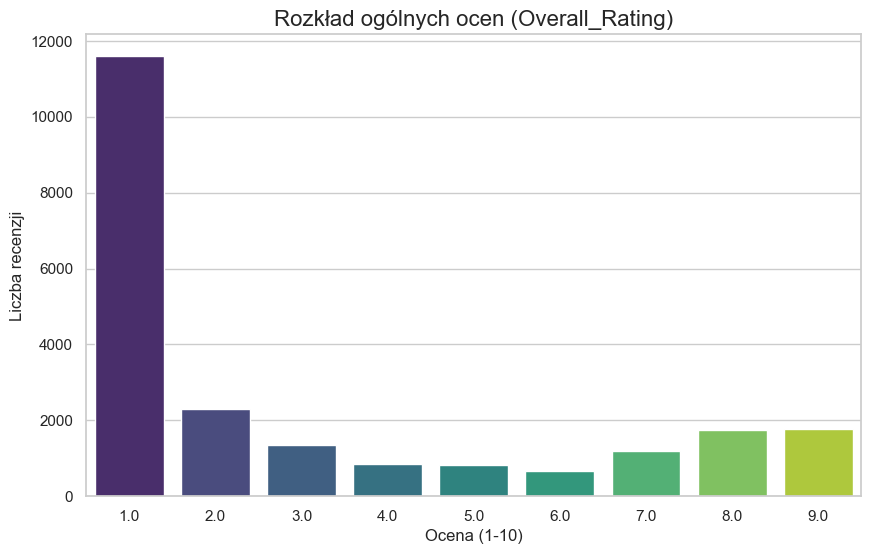

In [4]:
if not df.empty:
    # Sprawdzenie, czy kolumna 'Overall_Rating' istnieje
    if 'Overall_Rating' in df.columns:
        
        # Konwersja na typ numeryczny, na wypadek gdyby była wczytana jako obiekt (np. przez błąd w pliku)
        # 'coerce' zamieni błędy (np. tekst) na NaT/NaN
        df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.countplot(x='Overall_Rating', data=df, palette='viridis')
        plt.title('Rozkład ogólnych ocen (Overall_Rating)', fontsize=16)
        plt.xlabel('Ocena (1-10)', fontsize=12)
        plt.ylabel('Liczba recenzji', fontsize=12)
        plt.show()
    else:
        print("Kolumna 'Overall_Rating' nie została znaleziona w danych.")

In [6]:
import re # Biblioteka do wyrażeń regularnych
import nltk # Główna biblioteka do NLP

# Pobieranie niezbędnych zasobów NLTK
# 'punkt' - tokenizator (dzieli tekst na słowa)
# 'stopwords' - lista popularnych słów (np. "the", "a", "in") do usunięcia
# 'wordnet' - baza danych do lematyzacji (sprowadzania do formy podstawowej)
# 'omw-1.4' - Open Multilingual Wordnet, potrzebny dla WordNet
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

print("Pobrano i zaimportowano zasoby NLTK.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wojci\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wojci\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wojci\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\wojci\AppData\Roaming\nltk_data...


Pobrano i zaimportowano zasoby NLTK.


In [20]:
if not df.empty:
    # 1. Sprawdzenie braków w 'Review'
    print(f"Liczba wierszy przed usunięciem pustych recenzji: {len(df)}")
    df.dropna(subset=['Review'], inplace=True)
    print(f"Liczba wierszy po usunięciu pustych recenzji: {len(df)}")

    # 2. Uzupełnienie braków w 'Review_Title' pustym stringiem
    df['Review_Title'] = df['Review_Title'].fillna('')

    # 3. Połączenie tytułu i recenzji w jedną kolumnę
    # Dodajemy spację na wypadek, gdyby oba pola istniały
    df['full_text'] = df['Review_Title'] + " " + df['Review']

    # 4. Uzupełnienie braków w kluczowych metadanych kategorycznych
    cols_to_fill = ['Type Of Traveller', 'Seat Type', 'Route', 'Aircraft']
    for col in cols_to_fill:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')
    
    print("\nUtworzono kolumnę 'full_text' i uzupełniono braki w metadanych.")
    display(df.head(10))

Liczba wierszy przed usunięciem pustych recenzji: 23171
Liczba wierszy po usunięciu pustych recenzji: 23171

Utworzono kolumnę 'full_text' i uzupełniono braki w metadanych.


,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,full_text,cleaned_text,Dominant_Topic,Sentiment
0,AB Aviation,9.0,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,Unknown,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,1,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni moheli turned pre...,2,Pozytywna (8-10)
1,AB Aviation,1.0,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,0,"""Not a good airline"" Moroni to Anjouan. It is...",good airline moroni anjouan small airline tick...,7,Negatywna (1-3)
2,AB Aviation,1.0,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,0,"""flight was fortunately short"" Anjouan to Dz...",flight fortunately short anjouan dzaoudzi smal...,2,Negatywna (1-3)
3,Adria Airways,1.0,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,Unknown,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,0,"""I will never fly again with Adria"" Please d...",never fly adria please favor fly adria route m...,7,Negatywna (1-3)
4,Adria Airways,1.0,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,Unknown,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,"""it ruined our last days of holidays"" Do not ...",ruined last day holiday book flight airline fr...,7,Negatywna (1-3)
5,Adria Airways,1.0,"""Had very bad experience""",17th September 2019,True,Had very bad experience with rerouted and ca...,CR 900,Couple Leisure,Economy Class,Sarajevo to Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,"""Had very bad experience"" Had very bad exper...",bad experience bad experience rerouted cancell...,7,Negatywna (1-3)
6,Adria Airways,1.0,"""worse than the budget airlines""",6th September 2019,False,"Ljubljana to Zürich. Firstly, Ljubljana airp...",Unknown,Business,Economy Class,Ljubljana to Zürich,September 2019,1.0,1.0,1.0,1.0,NaN,NaN,1.0,0,"""worse than the budget airlines"" Ljubljana t...",worse budget airline ljubljana zrich firstly l...,3,Negatywna (1-3)
7,Adria Airways,1.0,"""book another company""",24th August 2019,False,"First of all, I am not complaining about a s...",Bombardier CRJ,Solo Leisure,Economy Class,Timisoara to Munich,August 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,"""book another company"" First of all, I am no...",book another company first complaining specifi...,7,Negatywna (1-3)
8,Adria Airways,1.0,"""combined two flights""",6th August 2019,True,Worst Airline ever! They combined two flight...,Unknown,Solo Leisure,Economy Class,Pristina to Zürich via Ljubliana,August 2019,1.0,2.0,1.0,1.0,1.0,1.0,1.0,0,"""combined two flights"" Worst Airline ever! T...",combined two flight worst airline ever combine...,3,Negatywna (1-3)
9,Adria Airways,8.0,"""the crew was nice""",12th October 2018,True,Ljubljana to Munich. The homebase airport of ...,Unknown,Family Leisure,Economy Class,Ljubljana to Munich,October 2018,4.0,4.0,3.0,5.0,NaN,NaN,5.0,1,"""the crew was nice"" Ljubljana to Munich. The ...",crew nice ljubljana munich homebase airport ad...,2,Pozytywna (8-10)


In [8]:
if not df.empty:
    # Konwersja 'Recommended' (yes/no) na format liczbowy (1/0)
    if 'Recommended' in df.columns:
        df['Recommended'] = df['Recommended'].map({'yes': 1, 'no': 0})
        print("\nPrzekonwertowano kolumnę 'Recommended' na 1 (yes) i 0 (no).")

    # Konwersja 'Verified' (True/False jako stringi) na typ boolean
    if 'Verified' in df.columns:
        df['Verified'] = df['Verified'].map({'True': True, 'False': False, True: True, False: False})
        print("Przekonwertowano kolumnę 'Verified' na typ Boolean.")


Przekonwertowano kolumnę 'Recommended' na 1 (yes) i 0 (no).
Przekonwertowano kolumnę 'Verified' na typ Boolean.


In [10]:
# Inicjalizacja lematyzatora i listy stopwords
lemmatizer = WordNetLemmatizer()
# Używamy angielskiej listy stopwords
stop_words = set(stopwords.words('english'))

# Możemy dodać własne, specyficzne dla domeny stopwords, jeśli zauważymy taką potrzebę
# np. "airline", "flight" - ale na razie zostawmy domyślne.
# custom_stopwords = {'airline', 'flight', 'flew'}
# stop_words.update(custom_stopwords)

def preprocess_text(text):
    """
    Funkcja do czyszczenia i preprocessingu tekstu recenzji.
    """
    if not isinstance(text, str):
        return ""

    # 1. Konwersja na małe litery
    text = text.lower()
    
    # 2. Usunięcie tagów HTML (jeśli istnieją)
    text = re.sub(r'<[^>]+>', '', text)
    
    # 3. Usunięcie znaków specjalnych, linków i "brudu" (np. '\xa0' z przykładu)
    text = re.sub(r'http\S+', '', text) # Usuwanie linków
    text = re.sub(r'\xa0', ' ', text) # Usuwanie nbsp
    
    # 4. Usunięcie znaków interpunkcyjnych i liczb - zostawiamy tylko litery
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Tokenizacja (podział na słowa)
    # Avoid dependency on NLTK 'punkt' tokenizer (fix for LookupError punkt_tab).
    # Since we've already removed non-letter characters, simple split is sufficient.
    tokens = text.split()
    
    # 6. Usunięcie stopwords i lematyzacja
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words and len(token) > 2: # Usuwamy też słowa krótsze niż 3 znaki
            # Lematyzacja (sprowadzenie do formy podstawowej, np. 'flying' -> 'fly')
            cleaned_tokens.append(lemmatizer.lemmatize(token))
            
    # 7. Połączenie tokenów z powrotem w jeden string
    return " ".join(cleaned_tokens)

# Przetestujmy funkcję na przykładowym tekście
test_review = """
<p>This is a test review! ✈️ It was an OKAY flight, but the seats were 100% uncomfortable. 
Check my blog: http://myblog.com. I was flying.</p>
"""
print(f"\n--- Test funkcji preprocess_text ---")
print(f"Oryginał: {test_review}")
print(f"Oczyszczony: {preprocess_text(test_review)}")


--- Test funkcji preprocess_text ---
Oryginał: 
<p>This is a test review! ✈️ It was an OKAY flight, but the seats were 100% uncomfortable. 
Check my blog: http://myblog.com. I was flying.</p>

Oczyszczony: test review okay flight seat uncomfortable check blog flying


In [22]:
if not df.empty:
    print("\nRozpoczynam czyszczenie kolumny 'full_text'. To może potrwać kilka minut...")
    
    # Zastosowanie funkcji do każdego wiersza w kolumnie 'full_text'
    # .progress_apply(preprocess_text) jeśli używasz tqdm
    df['cleaned_text'] = df['full_text'].apply(preprocess_text)
    
    print("Czyszczenie zakończone.")

    # 3. Usunięcie wierszy, które po czyszczeniu stały się puste
    # (np. recenzje typu "OK", "Good" - zostałyby odfiltrowane)
    df = df[df['cleaned_text'] != ""]
    print(f"Usunięto wiersze z pustym tekstem po czyszczeniu. Aktualna liczba wierszy: {len(df)}")

    # Wyświetlenie próbki z nową kolumną
    print("\n--- Próbka danych po czyszczeniu tekstu: ---")
    display(df[['full_text', 'cleaned_text', 'Overall_Rating']].head(10))


Rozpoczynam czyszczenie kolumny 'full_text'. To może potrwać kilka minut...
Czyszczenie zakończone.
Usunięto wiersze z pustym tekstem po czyszczeniu. Aktualna liczba wierszy: 23171

--- Próbka danych po czyszczeniu tekstu: ---


,full_text,cleaned_text,Overall_Rating
0,"""pretty decent airline"" Moroni to Moheli. Tu...",pretty decent airline moroni moheli turned pre...,9.0
1,"""Not a good airline"" Moroni to Anjouan. It is...",good airline moroni anjouan small airline tick...,1.0
2,"""flight was fortunately short"" Anjouan to Dz...",flight fortunately short anjouan dzaoudzi smal...,1.0
3,"""I will never fly again with Adria"" Please d...",never fly adria please favor fly adria route m...,1.0
4,"""it ruined our last days of holidays"" Do not ...",ruined last day holiday book flight airline fr...,1.0
5,"""Had very bad experience"" Had very bad exper...",bad experience bad experience rerouted cancell...,1.0
6,"""worse than the budget airlines"" Ljubljana t...",worse budget airline ljubljana zrich firstly l...,1.0
7,"""book another company"" First of all, I am no...",book another company first complaining specifi...,1.0
8,"""combined two flights"" Worst Airline ever! T...",combined two flight worst airline ever combine...,1.0
9,"""the crew was nice"" Ljubljana to Munich. The ...",crew nice ljubljana munich homebase airport ad...,8.0


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

print("Zaimportowano biblioteki do wektoryzacji i modelowania.")

Zaimportowano biblioteki do wektoryzacji i modelowania.


In [13]:
if 'df' in locals() and not df.empty:
    # Inicjalizacja wektoryzatora
    # Używamy CountVectorizer dla LDA
    vectorizer = CountVectorizer(max_df=0.9, 
                                 min_df=10, 
                                 ngram_range=(1, 2),
                                 stop_words='english') # Dodatkowe filtorwanie stopwords

    print("Rozpoczynam wektoryzację (CountVectorizer)...")
    
    # Dopasowanie i transformacja danych tekstowych
    dtm = vectorizer.fit_transform(df['cleaned_text'])
    
    # Pobranie nazw cech (słów/bigramów)
    feature_names = vectorizer.get_feature_names_out()
    
    print(f"Wektoryzacja zakończona.")
    print(f"Kształt macierzy Dokument-Termin (DTM): {dtm.shape}")
    print(f"Liczba recenzji (dokumentów): {dtm.shape[0]}")
    print(f"Liczba unikalnych słów/bigramów (cech): {dtm.shape[1]}")

    # Wyświetlenie próbki cech
    print("\n--- Próbka 20 cech (słów/bigramów): ---")
    print(list(feature_names[:20]))
else:
    print("DataFrame 'df' nie istnieje lub jest pusty. Uruchom poprzednie kroki.")

Rozpoczynam wektoryzację (CountVectorizer)...
Wektoryzacja zakończona.
Kształt macierzy Dokument-Termin (DTM): (23171, 19990)
Liczba recenzji (dokumentów): 23171
Liczba unikalnych słów/bigramów (cech): 19990

--- Próbka 20 cech (słów/bigramów): ---
['ababa', 'abandoned', 'aberdeen', 'ability', 'able', 'able access', 'able board', 'able book', 'able catch', 'able change', 'able check', 'able checkin', 'able contact', 'able flight', 'able fly', 'able help', 'able leave', 'able locate', 'able luggage', 'able make']


In [14]:
if 'dtm' in locals():
    # Ustawienie liczby tematów
    n_topics = 10
    
    # Inicjalizacja modelu LDA
    # n_components to liczba tematów (k)
    # random_state=42 zapewnia powtarzalność wyników
    lda_model = LatentDirichletAllocation(n_components=n_topics, 
                                          random_state=42,
                                          n_jobs=-1) # Użyj wszystkich dostępnych rdzeni CPU

    print(f"Rozpoczynam trenowanie modelu LDA z k={n_topics} tematami...")
    
    # Trenowanie modelu
    lda_model.fit(dtm)
    
    print("Trenowanie LDA zakończone.")

else:
    print("Macierz DTM nie została utworzona. Uruchom krok 3.1.")

Rozpoczynam trenowanie modelu LDA z k=10 tematami...
Trenowanie LDA zakończone.


In [15]:
def display_topics(model, feature_names, n_top_words):
    """
    Funkcja do wyświetlania top N słów dla każdego tematu w modelu.
    """
    for topic_idx, topic in enumerate(model.components_):
        # model.components_ przechowuje wagi słów dla każdego tematu
        # Bierzemy n_top_words słów o najwyższej wadze
        top_words_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_indices]
        
        print(f"--- Temat #{topic_idx+1}: ---")
        print(" ".join(top_words))
        print("\n")

# Liczba słów do wyświetlenia dla każdego tematu
n_top_words = 15

if 'lda_model' in locals() and 'feature_names' in locals():
    print(f"--- Najważniejsze słowa dla {n_topics} tematów (Model LDA): ---")
    display_topics(lda_model, feature_names, n_top_words)
else:
    print("Model LDA nie został wytrenowany. Uruchom poprzednie kroki.")

--- Najważniejsze słowa dla 10 tematów (Model LDA): ---
--- Temat #1: ---
flight seat meal food airline hour drink entertainment served economy hong kong movie hong kong cabin


--- Temat #2: ---
flight gate boarding hour minute time plane check airport passenger told line counter late staff


--- Temat #3: ---
flight crew good time cabin friendly seat staff cabin crew aircraft nice service comfortable great clean


--- Temat #4: ---
flight hour airline delayed airport day delay time hotel flight delayed cancelled delayed hour fly staff connecting


--- Temat #5: ---
bag luggage airline baggage pay check extra checked airport lost carry ticket charge staff cost


--- Temat #6: ---
service class business business class food airline good staff economy lounge seat flight excellent experience cabin


--- Temat #7: ---
seat flight plane attendant hour passenger row asked told didnt flight attendant staff time extra paid


--- Temat #8: ---
flight customer service ticket customer service ref

In [16]:
if 'df' in locals() and not df.empty:
    print("\n--- Rozpoczynam pipeline dla modelu NMF (TF-IDF) ---")
    
    # 1. Wektoryzacja TF-IDF (inne ustawienia niż dla CountVectorizer)
    tfidf_vectorizer = TfidfVectorizer(max_df=0.9, 
                                       min_df=10, 
                                       ngram_range=(1, 2),
                                       stop_words='english')
    
    tfidf_dtm = tfidf_vectorizer.fit_transform(df['cleaned_text'])
    tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

    # 2. Model NMF
    nmf_model = NMF(n_components=n_topics, 
                    random_state=42,
                    max_iter=500) # NMF może potrzebować więcej iteracji

    print("Trenowanie modelu NMF...")
    nmf_model.fit(tfidf_dtm)
    print("Trenowanie NMF zakończone.")

    # 3. Wyświetlenie wyników NMF
    print(f"\n--- Najważniejsze słowa dla {n_topics} tematów (Model NMF z TF-IDF): ---")
    display_topics(nmf_model, tfidf_feature_names, n_top_words)


--- Rozpoczynam pipeline dla modelu NMF (TF-IDF) ---
Trenowanie modelu NMF...
Trenowanie NMF zakończone.

--- Najważniejsze słowa dla 10 tematów (Model NMF z TF-IDF): ---
--- Temat #1: ---
flight hour delayed delay time airport flight delayed plane delayed hour minute gate passenger late hotel connecting


--- Temat #2: ---
good flight staff food great service friendly nice comfortable time experience meal excellent overall entertainment


--- Temat #3: ---
refund flight ticket cancelled day email money booked month flight cancelled change airline cancelled flight cancel received


--- Temat #4: ---
bag luggage check baggage pay checked lost airport carry extra told staff hand boarding counter


--- Temat #5: ---
class business business class economy lounge class seat economy class food service premium meal flat passenger class passenger product


--- Temat #6: ---
worst airline worst airline experience worst experience ive flown fly recommend airline worst dont rude airline flown fly

Rozpoczynam optymalizację hiperparametru 'k' (liczba tematów)...
Zakończono dla k=5, Wynik Log-Likelihood: -14303714.11
Zakończono dla k=6, Wynik Log-Likelihood: -14294331.95
Zakończono dla k=7, Wynik Log-Likelihood: -14303791.60
Zakończono dla k=8, Wynik Log-Likelihood: -14276995.54
Zakończono dla k=9, Wynik Log-Likelihood: -14286094.22
Zakończono dla k=10, Wynik Log-Likelihood: -14288171.67
Zakończono dla k=11, Wynik Log-Likelihood: -14279126.44
Zakończono dla k=12, Wynik Log-Likelihood: -14288526.28
Zakończono dla k=13, Wynik Log-Likelihood: -14312510.07
Zakończono dla k=14, Wynik Log-Likelihood: -14316366.35
Zakończono dla k=15, Wynik Log-Likelihood: -14312570.26
Zakończono dla k=16, Wynik Log-Likelihood: -14316355.48
Zakończono dla k=17, Wynik Log-Likelihood: -14305873.00
Zakończono dla k=18, Wynik Log-Likelihood: -14317999.60
Zakończono dla k=19, Wynik Log-Likelihood: -14321531.86
Zakończono dla k=20, Wynik Log-Likelihood: -14328429.80
Optymalizacja zakończona.


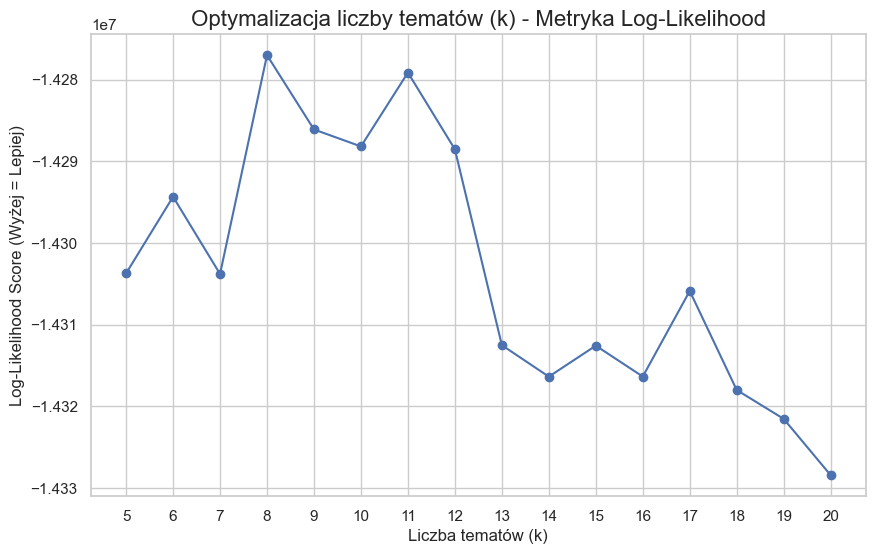

In [17]:
if 'dtm' in locals():
    print("Rozpoczynam optymalizację hiperparametru 'k' (liczba tematów)...")
    
    # Zakres 'k' do przetestowania
    k_range = range(5, 21) # Przetestujemy od 5 do 20 tematów
    log_likelihood_scores = []
    
    for k in k_range:
        lda_model_test = LatentDirichletAllocation(n_components=k, 
                                                 random_state=42, 
                                                 n_jobs=-1)
        lda_model_test.fit(dtm)
        
        # Obliczamy log-likelihood i zapisujemy
        log_likelihood_scores.append(lda_model_test.score(dtm))
        print(f"Zakończono dla k={k}, Wynik Log-Likelihood: {log_likelihood_scores[-1]:.2f}")

    print("Optymalizacja zakończona.")

    # Wizualizacja wyników
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, log_likelihood_scores, marker='o')
    plt.title('Optymalizacja liczby tematów (k) - Metryka Log-Likelihood', fontsize=16)
    plt.xlabel('Liczba tematów (k)', fontsize=12)
    plt.ylabel('Log-Likelihood Score (Wyżej = Lepiej)', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()
else:
    print("Brak macierzy DTM. Uruchom Krok 3.")

In [18]:
if 'dtm' in locals():
    # Ustawiamy k na podstawie wyników optymalizacji
    # (Tymczasowo ustawiam 12, Ty wybierz wartość ze swojego wykresu)
    K_OPTIMAL = 8
    
    print(f"Rozpoczynam trenowanie finalnego modelu LDA z k={K_OPTIMAL}...")
    
    # Trenujemy finalny model
    final_lda_model = LatentDirichletAllocation(n_components=K_OPTIMAL, 
                                              random_state=42, 
                                              n_jobs=-1)
    final_lda_model.fit(dtm)
    
    print("Trenowanie finalnego modelu zakończone.")
    
    # ----------------------------------------------------
    # Przypisanie tematów do recenzji
    # ----------------------------------------------------
    print("Rozpoczynam przypisywanie tematów do recenzji...")
    
    # Używamy .transform(), aby uzyskać rozkład prawdopodobieństwa tematów dla każdej recenzji
    topic_probabilities = final_lda_model.transform(dtm)
    
    # Znajdujemy temat o najwyższym prawdopodobieństwie dla każdej recenzji
    # np.argmax() zwraca indeks tematu (0 do K_OPTIMAL-1)
    df['Dominant_Topic'] = np.argmax(topic_probabilities, axis=1)
    
    print("Przypisano dominujący temat do każdej recenzji.")
    
    # Wyświetlenie próbki z nową kolumną
    display(df[['cleaned_text', 'Overall_Rating', 'Dominant_Topic']].head())
    
    # Wyświetlenie tematów z finalnego modelu
    print(f"\n--- Tematy z finalnego modelu (k={K_OPTIMAL}): ---")
    display_topics(final_lda_model, feature_names, n_top_words=15)
    
else:
    print("Brak macierzy DTM. Uruchom Krok 3.")

Rozpoczynam trenowanie finalnego modelu LDA z k=8...
Trenowanie finalnego modelu zakończone.
Rozpoczynam przypisywanie tematów do recenzji...
Przypisano dominujący temat do każdej recenzji.


,cleaned_text,Overall_Rating,Dominant_Topic
0,pretty decent airline moroni moheli turned pre...,9.0,2
1,good airline moroni anjouan small airline tick...,1.0,7
2,flight fortunately short anjouan dzaoudzi smal...,1.0,2
3,never fly adria please favor fly adria route m...,1.0,7
4,ruined last day holiday book flight airline fr...,1.0,7



--- Tematy z finalnego modelu (k=8): ---
--- Temat #1: ---
flight seat food airline meal class economy good business drink entertainment hour cabin crew service


--- Temat #2: ---
flight hour gate boarding time plane minute airline worst check airport passenger late told line


--- Temat #3: ---
flight crew good time review customer review friendly customer cabin airline air aircraft service seat staff


--- Temat #4: ---
flight hour airline delayed airport day delay time hotel flight delayed fly staff cancelled delayed hour customer


--- Temat #5: ---
bag luggage airline baggage pay check extra checked airport ticket lost carry staff cost charge


--- Temat #6: ---
service staff class airline business good business class food flight experience lounge time air excellent ground


--- Temat #7: ---
seat flight plane air passenger attendant hour row crew staff flight attendant time asked didnt leg


--- Temat #8: ---
flight customer service ticket customer service refund airline day ti

In [19]:
if 'df' in locals() and 'Dominant_Topic' in df.columns:
    # Tworzenie kolumny sentymentu
    def categorize_sentiment(rating):
        if rating >= 8:
            return 'Pozytywna (8-10)'
        elif rating <= 3:
            return 'Negatywna (1-3)'
        else:
            return 'Neutralna (4-7)'

    df['Sentiment'] = df['Overall_Rating'].apply(categorize_sentiment)
    
    print("Utworzono kolumnę 'Sentiment' na podstawie 'Overall_Rating'.")
    display(df[['Overall_Rating', 'Sentiment']].head())

Utworzono kolumnę 'Sentiment' na podstawie 'Overall_Rating'.


,Overall_Rating,Sentiment
0,9.0,Pozytywna (8-10)
1,1.0,Negatywna (1-3)
2,1.0,Negatywna (1-3)
3,1.0,Negatywna (1-3)
4,1.0,Negatywna (1-3)
